<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Identification_of_Renewable_Energy%E2%80%93Climate_Regimes_Using_UMAP_Based_Unsupervised_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ==============================
# Import Required Libraries
# ==============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import umap.umap_ as umap

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# ==============================
# Load Dataset
# ==============================

df = pd.read_csv("/content/drive/MyDrive/Dataset/renewable_energy_climate_nexus.csv")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (1253, 18)


,Date,Clean_Energy_Close,Clean_Energy_Volume,Solar_Close,Solar_Volume,Wind_Close,Wind_Volume,Traditional_Energy_Close,Traditional_Energy_Volume,Texas_USA_Max_Temp_C,Texas_USA_Max_Wind_kmh,Texas_USA_Solar_Radiation_MJm2,Cali_USA_Max_Temp_C,Cali_USA_Max_Wind_kmh,Cali_USA_Solar_Radiation_MJm2,Germany_Max_Temp_C,Germany_Max_Wind_kmh,Germany_Solar_Radiation_MJm2
0,2021-03-15,23.621262,4867900,95.807014,1782400,20.299355,154400,21.920404,60452600,23.0,20.9,23.03,8.9,49.2,9.73,6.7,23.1,9.01
1,2021-03-16,23.079960,7287700,93.808754,1898600,20.299355,137700,21.295408,77287000,27.0,30.1,14.01,15.9,33.8,22.46,6.4,23.1,11.04
2,2021-03-17,22.445333,8889100,92.556114,1607200,19.994171,239500,21.460976,64552200,19.0,46.6,23.24,17.5,11.3,21.03,4.5,14.5,9.81
3,2021-03-18,21.222738,10105500,86.461929,2929900,19.559515,105100,20.496580,87207200,16.6,28.9,23.44,23.1,20.0,22.33,5.6,12.8,13.71
4,2021-03-19,21.782703,7793700,89.056679,2551000,19.809206,58000,20.500715,81158600,16.5,15.8,23.50,24.0,24.1,20.64,4.3,17.8,12.47


In [5]:
# ==============================
# Dataset Information
# ==============================

df.info()

print("\n")

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            1253 non-null   object 
 1   Clean_Energy_Close              1253 non-null   float64
 2   Clean_Energy_Volume             1253 non-null   int64  
 3   Solar_Close                     1253 non-null   float64
 4   Solar_Volume                    1253 non-null   int64  
 5   Wind_Close                      1253 non-null   float64
 6   Wind_Volume                     1253 non-null   int64  
 7   Traditional_Energy_Close        1253 non-null   float64
 8   Traditional_Energy_Volume       1253 non-null   int64  
 9   Texas_USA_Max_Temp_C            1253 non-null   float64
 10  Texas_USA_Max_Wind_kmh          1253 non-null   float64
 11  Texas_USA_Solar_Radiation_MJm2  1253 non-null   float64
 12  Cali_USA_Max_Temp_C             12

In [6]:
# ==============================
# Check Missing Values
# ==============================

print(df.isnull().sum())

Date                              0
Clean_Energy_Close                0
Clean_Energy_Volume               0
Solar_Close                       0
Solar_Volume                      0
Wind_Close                        0
Wind_Volume                       0
Traditional_Energy_Close          0
Traditional_Energy_Volume         0
Texas_USA_Max_Temp_C              0
Texas_USA_Max_Wind_kmh            0
Texas_USA_Solar_Radiation_MJm2    0
Cali_USA_Max_Temp_C               0
Cali_USA_Max_Wind_kmh             0
Cali_USA_Solar_Radiation_MJm2     0
Germany_Max_Temp_C                0
Germany_Max_Wind_kmh              0
Germany_Solar_Radiation_MJm2      0
dtype: int64


In [22]:
# Remove Date Column
# ==============================

X = df.drop(columns=["Date"])

print("\nFeatures used for clustering:")
print(X.columns)


Features used for clustering:
Index(['Clean_Energy_Close', 'Clean_Energy_Volume', 'Solar_Close',
       'Solar_Volume', 'Wind_Close', 'Wind_Volume', 'Traditional_Energy_Close',
       'Traditional_Energy_Volume', 'Texas_USA_Max_Temp_C',
       'Texas_USA_Max_Wind_kmh', 'Texas_USA_Solar_Radiation_MJm2',
       'Cali_USA_Max_Temp_C', 'Cali_USA_Max_Wind_kmh',
       'Cali_USA_Solar_Radiation_MJm2', 'Germany_Max_Temp_C',
       'Germany_Max_Wind_kmh', 'Germany_Solar_Radiation_MJm2'],
      dtype='object')


In [23]:
# Standardization
# ==============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [24]:
# ==============================
# UMAP Embedding
# ==============================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)

print("Embedding Shape:", embedding.shape)


Embedding Shape: (1253, 2)


In [25]:
# ==============================
# Find Best Number of Clusters
# ==============================

scores = {}

for k in range(2,9):

    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(embedding)

    scores[k] = silhouette_score(embedding, labels)

best_k = max(scores, key=scores.get)

print("\nSilhouette Scores")
for k,v in scores.items():
    print(f"k={k}: {v:.4f}")

print("\nBest Number of Clusters =", best_k)



Silhouette Scores
k=2: 0.6114
k=3: 0.5757
k=4: 0.5935
k=5: 0.6333
k=6: 0.5935
k=7: 0.5940
k=8: 0.5585

Best Number of Clusters = 5


In [28]:
# ==============================
# Clustering Models
# ==============================

models = {
    "K-Means":
        KMeans(
            n_clusters=best_k,
            random_state=42,
            n_init=10
        ),

    "Hierarchical":
        AgglomerativeClustering(
            n_clusters=best_k,
            linkage="ward"
        )
}

labels = {}

for name, model in models.items():
    labels[name] = model.fit_predict(embedding)

# ==============================
# Evaluation Function
# ==============================

def evaluate(cluster_labels):

    return {
        "Silhouette":
            silhouette_score(embedding, cluster_labels),

        "Calinski-Harabasz":
            calinski_harabasz_score(embedding, cluster_labels),

        "Davies-Bouldin":
            davies_bouldin_score(embedding, cluster_labels)
    }

results = pd.DataFrame({
    name: evaluate(lbl)
    for name, lbl in labels.items()
}).T

results = results.round(4)

print("\nClustering Performance")
display(results)


Clustering Performance


,Silhouette,Calinski-Harabasz,Davies-Bouldin
K-Means,0.6333,5886.9292,0.4932
Hierarchical,0.6336,5886.6455,0.4930


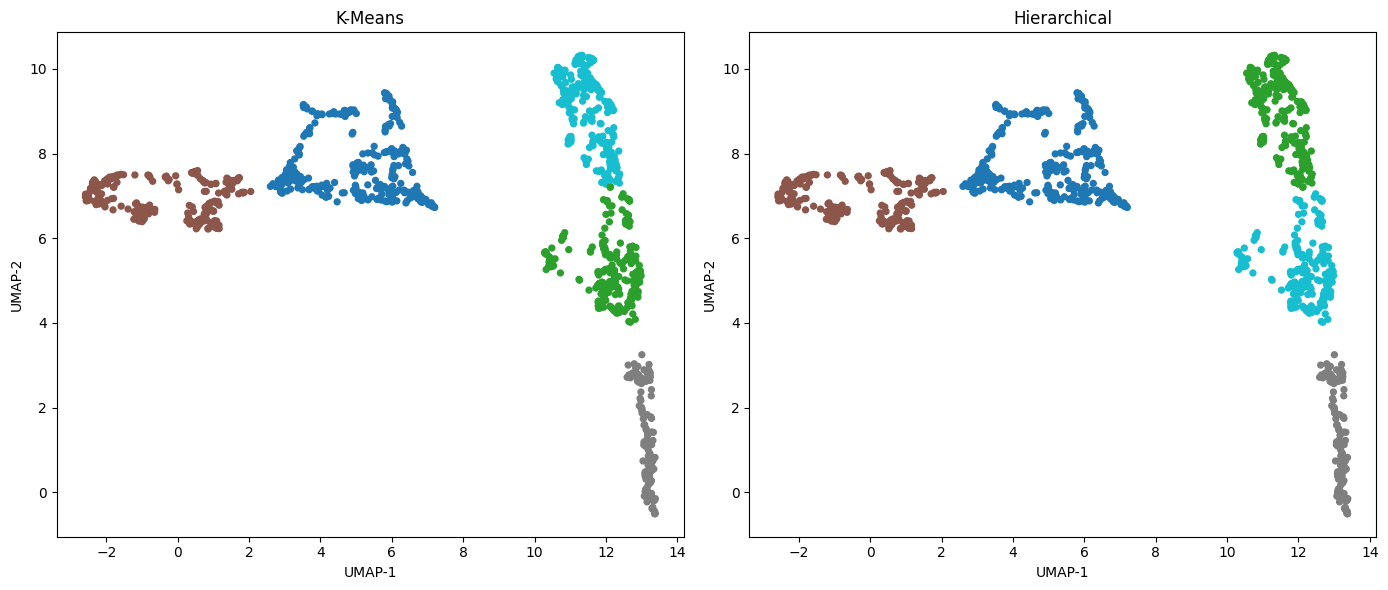

In [21]:
# ==============================
# UMAP Visualization
# ==============================

fig, axes = plt.subplots(1,2, figsize=(14,6))

for ax, (name, lbl) in zip(axes, labels.items()):

    scatter = ax.scatter(
        embedding[:,0],
        embedding[:,1],
        c=lbl,
        cmap="tab10",
        s=18
    )

    ax.set_title(name)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()


In [29]:
# Add cluster labels to original dataframe
df_cluster = df.copy()
df_cluster["Cluster"] = labels["K-Means"]

# Mean of each variable in each cluster
cluster_profile = df_cluster.groupby("Cluster").mean(numeric_only=True)

display(cluster_profile.round(2))

,Clean_Energy_Close,Clean_Energy_Volume,Solar_Close,Solar_Volume,Wind_Close,Wind_Volume,Traditional_Energy_Close,Traditional_Energy_Volume,Texas_USA_Max_Temp_C,Texas_USA_Max_Wind_kmh,Texas_USA_Solar_Radiation_MJm2,Cali_USA_Max_Temp_C,Cali_USA_Max_Wind_kmh,Cali_USA_Solar_Radiation_MJm2,Germany_Max_Temp_C,Germany_Max_Wind_kmh,Germany_Solar_Radiation_MJm2
Cluster,,,,,,,,,,,,,,,,,
0,18.75,5053044.90,73.87,1061140.23,16.75,82727.41,36.75,49625475.80,28.13,25.80,20.44,26.26,27.17,22.80,16.08,17.93,14.14
1,13.51,2791652.23,41.27,1034363.97,16.48,44897.98,42.19,33546611.34,33.09,23.12,24.14,34.09,27.09,27.62,21.91,15.94,19.37
2,20.77,5456320.23,80.70,1472256.87,19.40,151269.47,24.00,65492288.55,24.94,24.26,18.43,25.90,25.97,20.90,13.02,18.45,10.82
3,16.29,3585629.75,48.07,1027906.96,20.17,43760.76,46.15,38467763.29,24.77,20.15,16.44,23.08,16.59,15.59,10.24,16.72,6.62
4,12.62,3570923.87,40.29,1127032.10,14.86,48879.84,41.86,33490264.20,19.73,23.52,14.91,17.51,19.95,14.77,8.47,19.35,5.61


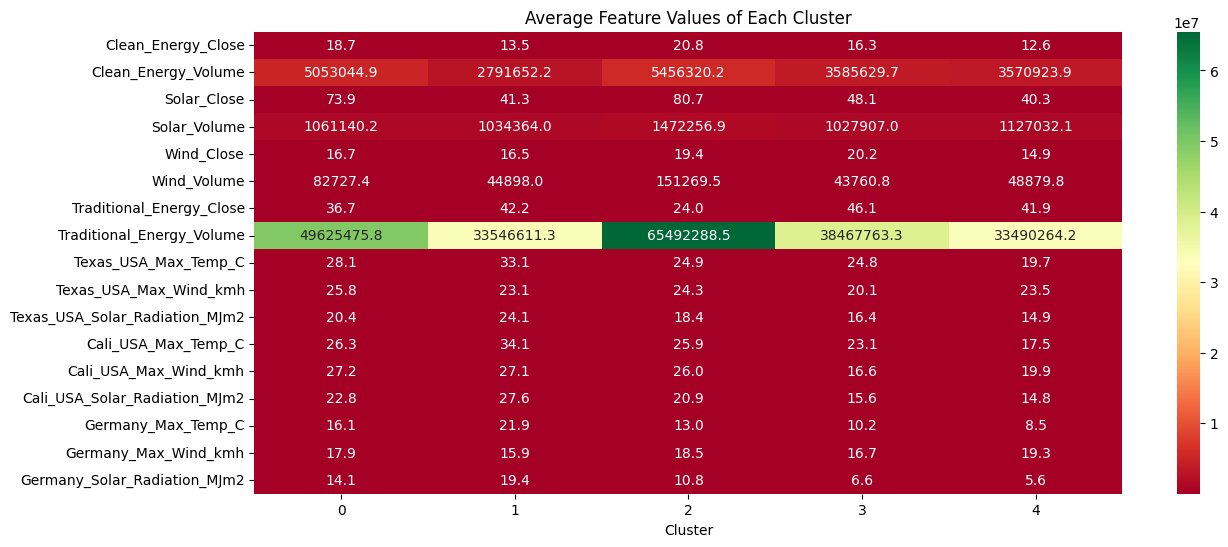

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.heatmap(cluster_profile.T,
            cmap="RdYlGn",
            annot=True,
            fmt=".1f")

plt.title("Average Feature Values of Each Cluster")
plt.show()